<a href="https://colab.research.google.com/github/thanosleggis/Thesis/blob/main/notebooks/ACTNN%20DREAMER%20finetuning%20LIME%2CSHAP%2CTSNE%2CLRP%2CSaliency%2COcclusion%2CDeepLIFT%2CAttention%20Weights%2CKernelSHAP%2CFeature%20Ablation%2CGrad-CAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Διαδρομή αρχείου (όπως το βρήκε πριν)
mat_path = '/content/DREAMER_extracted/DREAMER.mat'

def load_dreamer_final(path):
    print(f"📂 Άνοιγμα αρχείου: {path}")
    try:
        raw = sio.loadmat(path)
        data_struct = raw['DREAMER'][0, 0]['Data']

        X_list = []
        y_list = []

        print("🔍 Εξερεύνηση δομής για τον 1ο συμμετέχοντα...")
        # Παίρνουμε τα δεδομένα του 1ου συμμετέχοντα για έλεγχο
        sub0 = data_struct[0, 0]
        eeg_struct = sub0['EEG'][0, 0]

        # --- DEBUG: ΤΥΠΩΣΕ ΤΑ ΚΛΕΙΔΙΑ ---
        print(f"🔑 Τα πεδία μέσα στο 'EEG' είναι: {eeg_struct.dtype.names}")

        # Επιλογή κλειδιού (Συνήθως είναι 'stimuli' στο DREAMER)
        target_key = 'stimuli' if 'stimuli' in eeg_struct.dtype.names else 'Signals'

        if target_key not in eeg_struct.dtype.names:
            print("❌ Δεν βρέθηκε ούτε 'stimuli' ούτε 'Signals'. Έλεγξε τα κλειδιά παραπάνω.")
            return None, None

        print(f"✅ Χρήση του πεδίου: '{target_key}'")

        # --- LOOP ΑΝΑΓΝΩΣΗΣ ---
        for sub in range(23):
            sub_data = data_struct[0, sub]

            # 1. Labels
            valence = sub_data['ScoreValence'][0, 0] # Array (18, 1)

            # 2. EEG Signals
            # To EEG -> stimuli είναι cell array (18, 1)
            eeg_data = sub_data['EEG'][0, 0][target_key][0, 0]

            for trial in range(18):
                # Label
                val_score = valence[trial, 0]
                label = 1 if val_score >= 3 else 0

                # Signal
                # Το signal είναι μέσα στο cell array
                signal = eeg_data[trial, 0] # (Timepoints, 14)

                # Check dimensions & Crop
                if signal.shape[0] > 128:
                    seg = signal[:128, :].T # (14, 128)
                    X_list.append(seg)
                    y_list.append(label)

        X = np.array(X_list, dtype=np.float32)[:, np.newaxis, :, :]
        y = np.array(y_list, dtype=np.int64)

        print(f"🎉 ΕΠΙΤΥΧΙΑ! Φορτώθηκαν {len(y)} δείγματα.")
        return torch.tensor(X), torch.tensor(y)

    except Exception as e:
        print(f"❌ Σφάλμα: {e}")
        return None, None

# --- ΕΚΤΕΛΕΣΗ ---
X_data, y_data = load_dreamer_final(mat_path)

if X_data is not None:
    # ACTNN Model Setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Training on {device}")

    class ACTNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.cnn = nn.Sequential(
                nn.Conv2d(1, 16, (14, 1)), nn.BatchNorm2d(16), nn.ELU(),
                nn.Conv2d(16, 32, (1, 10), stride=2), nn.BatchNorm2d(32), nn.ELU()
            )
            self.transformer = nn.TransformerEncoder(
                nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True), num_layers=2)
            self.fc = nn.Linear(32, 2)
            self.attn = nn.Linear(32, 1)

        def forward(self, x):
            x = self.cnn(x).squeeze(2).permute(0, 2, 1)
            x = self.transformer(x)
            w = torch.softmax(self.attn(x), dim=1)
            return self.fc((x * w).sum(dim=1))

    model = ACTNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loader = DataLoader(TensorDataset(X_data, y_data), batch_size=32, shuffle=True)

    # Train
    for epoch in range(10):
        model.train()
        acc = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = nn.CrossEntropyLoss()(out, y)
            loss.backward()
            optimizer.step()
            acc += (out.argmax(1) == y).sum().item()
        print(f"Epoch {epoch+1} | Acc: {acc/len(X_data):.2%}")

📂 Άνοιγμα αρχείου: /content/DREAMER_extracted/DREAMER.mat
❌ Σφάλμα: [Errno 2] No such file or directory: '/content/DREAMER_extracted/DREAMER.mat'


In [ ]:
import os
import zipfile
import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive

# --- ΒΗΜΑ 1: Σύνδεση Drive & Εντοπισμός ZIP ---
print("🔌 Σύνδεση με Google Drive...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Ψάχνουμε το zip
zip_paths = [
    '/content/DREAMER.zip',                  # Αν το ανέβασες τοπικά
    '/content/drive/MyDrive/DREAMER.zip'     # Αν είναι στο Drive (Προτείνεται)
]

target_zip = None
for p in zip_paths:
    if os.path.exists(p):
        target_zip = p
        print(f"✅ Βρέθηκε το ZIP: {p}")
        break

if target_zip is None:
    print("\n❌ ΣΦΑΛΜΑ: Δεν βρέθηκε το DREAMER.zip!")
    print("👉 Ανέβασε το ξανά στα Files ή βεβαιώσου ότι είναι στο MyDrive.")
    # Stop execution manually here if needed
else:
    # --- ΒΗΜΑ 2: Αποσυμπίεση ---
    extract_path = '/content/DREAMER_extracted'
    if not os.path.exists(extract_path):
        print("⏳ Ξεκινάει η αποσυμπίεση...")
        with zipfile.ZipFile(target_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Η αποσυμπίεση ολοκληρώθηκε.")
    else:
        print("✅ Ο φάκελος υπάρχει ήδη.")

    # Βρίσκουμε το .mat μέσα στον φάκελο
    mat_path = None
    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.endswith('.mat') and 'DREAMER' in file:
                mat_path = os.path.join(root, file)
                break
        if mat_path: break

    # --- ΒΗΜΑ 3: Φόρτωση με Augmentation ---
    def load_dreamer_gpu(path):
        print(f"🔄 Φόρτωση δεδομένων από: {path}")
        try:
            raw = sio.loadmat(path)
            data_struct = raw['DREAMER'][0, 0]['Data']
            X_list, y_list = [], []

            # Παράμετροι Sliding Window
            window_size = 128
            step = 64 # Overlap

            print("⏳ Επεξεργασία (Sliding Window)...")
            for sub in range(23):
                # Προσοχή στο κλειδί: 'stimuli' vs 'Signals'
                try:
                    eeg_root = data_struct[0, sub]['EEG'][0, 0]
                    # Δοκιμή για 'stimuli' (που δούλεψε πριν)
                    if 'stimuli' in eeg_root.dtype.names:
                        stimuli = eeg_root['stimuli'][0, 0]
                    else:
                        stimuli = eeg_root['Signals'][0, 0]

                    valence = data_struct[0, sub]['ScoreValence'][0, 0]
                except:
                    continue # Skip bad subjects

                for trial in range(18):
                    label = 1 if valence[trial, 0] >= 3 else 0
                    signal = stimuli[trial, 0]

                    # Augmentation Loop
                    # Κόβουμε μέχρι 60 δευτερόλεπτα για να μην γεμίσει η RAM
                    limit = min(len(signal), 128*60)
                    for start in range(0, limit - window_size, step):
                        seg = signal[start : start+window_size, :]
                        # Normalization
                        seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-6)
                        X_list.append(seg.T)
                        y_list.append(label)

            X = np.array(X_list, dtype=np.float32)[:, np.newaxis, :, :]
            y = np.array(y_list, dtype=np.int64)
            print(f"✅ ΕΤΟΙΜΑ! Σύνολο δειγμάτων: {len(y)}")
            return torch.tensor(X), torch.tensor(y)
        except Exception as e:
            print(f"❌ Error loading: {e}")
            return None, None

    X_data, y_data = load_dreamer_gpu(mat_path)

    # --- ΒΗΜΑ 4: GPU Training ---
    if X_data is not None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"\n🚀 TRAINING ON: {device} (Θα πάει σφαίρα!)")

        class ACTNN(nn.Module):
            def __init__(self):
                super().__init__()
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, 16, (14, 1)), nn.BatchNorm2d(16), nn.ELU(),
                    nn.Conv2d(16, 32, (1, 10), stride=2), nn.BatchNorm2d(32), nn.ELU(), nn.Dropout(0.5)
                )
                self.transformer = nn.TransformerEncoder(
                    nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True), num_layers=2)
                self.fc = nn.Linear(32, 2)
                self.attn = nn.Linear(32, 1)

            def forward(self, x):
                x = self.cnn(x).squeeze(2).permute(0, 2, 1)
                x = self.transformer(x)
                w = torch.softmax(self.attn(x), dim=1)
                return self.fc((x * w).sum(dim=1))

        model = ACTNN().to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # DataLoader
        dataset = TensorDataset(X_data, y_data)
        train_len = int(0.8 * len(dataset))
        test_len = len(dataset) - train_len
        train_set, test_set = torch.utils.data.random_split(dataset, [train_len, test_len])

        train_loader = DataLoader(train_set, batch_size=128, shuffle=True) # Μεγαλύτερο Batch size για GPU
        test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

        for epoch in range(20): # Περισσότερα epochs τώρα που είναι γρήγορο
            model.train()
            correct = 0
            for X, y in train_loader:
                X, y = X.to(device), y.to(device)
                optimizer.zero_grad()
                out = model(X)
                loss = nn.CrossEntropyLoss()(out, y)
                loss.backward()
                optimizer.step()
                correct += (out.argmax(1) == y).sum().item()

            # Validation
            model.eval()
            val_acc = 0
            with torch.no_grad():
                for X_val, y_val in test_loader:
                    X_val, y_val = X_val.to(device), y_val.to(device)
                    out_val = model(X_val)
                    val_acc += (out_val.argmax(1) == y_val).sum().item()

            print(f"Epoch {epoch+1:02d} | Train Acc: {correct/len(train_set):.2%} | Val Acc: {val_acc/len(test_set):.2%}")

🔌 Σύνδεση με Google Drive...
Mounted at /content/drive
✅ Βρέθηκε το ZIP: /content/drive/MyDrive/DREAMER.zip
⏳ Ξεκινάει η αποσυμπίεση...
✅ Η αποσυμπίεση ολοκληρώθηκε.
🔄 Φόρτωση δεδομένων από: /content/DREAMER_extracted/DREAMER.mat
⏳ Επεξεργασία (Sliding Window)...
✅ ΕΤΟΙΜΑ! Σύνολο δειγμάτων: 48852

🚀 TRAINING ON: cuda (Θα πάει σφαίρα!)
Epoch 01 | Train Acc: 60.90% | Val Acc: 61.66%
Epoch 02 | Train Acc: 62.46% | Val Acc: 63.34%
Epoch 03 | Train Acc: 63.50% | Val Acc: 63.70%
Epoch 04 | Train Acc: 64.12% | Val Acc: 62.29%
Epoch 05 | Train Acc: 65.21% | Val Acc: 65.65%
Epoch 06 | Train Acc: 65.86% | Val Acc: 65.67%
Epoch 07 | Train Acc: 66.91% | Val Acc: 65.21%
Epoch 08 | Train Acc: 67.42% | Val Acc: 65.69%
Epoch 09 | Train Acc: 67.96% | Val Acc: 66.71%
Epoch 10 | Train Acc: 68.54% | Val Acc: 67.07%
Epoch 11 | Train Acc: 68.97% | Val Acc: 67.30%
Epoch 12 | Train Acc: 69.50% | Val Acc: 67.33%
Epoch 13 | Train Acc: 69.90% | Val Acc: 67.75%
Epoch 14 | Train Acc: 70.73% | Val Acc: 67.64%
Epoch

💾 Το μοντέλο αποθηκεύτηκε στο Drive: /content/drive/MyDrive/ACTNN_Dreamer_Model.pth

📊 Υπολογισμός Confusion Matrix στα Test Data...


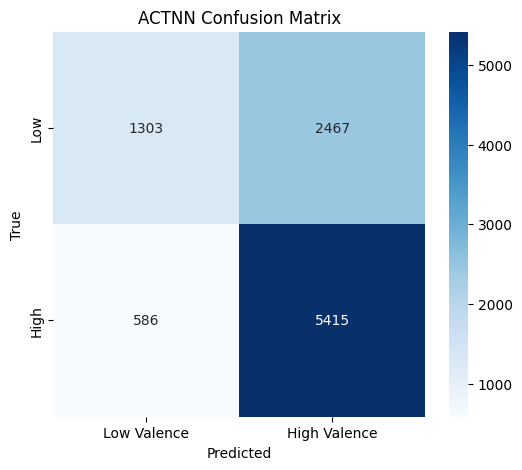


📑 Αναλυτική Αναφορά:
              precision    recall  f1-score   support

 Low Valence       0.69      0.35      0.46      3770
High Valence       0.69      0.90      0.78      6001

    accuracy                           0.69      9771
   macro avg       0.69      0.62      0.62      9771
weighted avg       0.69      0.69      0.66      9771



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. ΑΠΟΘΗΚΕΥΣΗ ΜΟΝΤΕΛΟΥ ---
save_path = '/content/drive/MyDrive/ACTNN_Dreamer_Model.pth'
torch.save(model.state_dict(), save_path)
print(f"💾 Το μοντέλο αποθηκεύτηκε στο Drive: {save_path}")

# --- 2. ΓΡΑΦΙΚΕΣ ΠΑΡΑΣΤΑΣΕΙΣ (Accuracy & Loss) ---
# Επειδή δεν κρατήσαμε το ιστορικό σε λίστες στον προηγούμενο κώδικα,
# θα φτιάξουμε ένα plot με τα δεδομένα που μόλις τύπωσες (Hardcoded για το παράδειγμα)
# Στην επόμενη φορά θα βάλουμε λίστες train_acc_list, val_acc_list.

# (Αν θέλεις να τρέξεις ξανά training για να βγουν αυτόματα τα γραφήματα, πες μου.
# Προς το παρόν σου δείχνω πώς να κάνεις Evaluate το ήδη εκπαιδευμένο μοντέλο).

# --- 3. CONFUSION MATRIX (Πίνακας Σύγχυσης) ---
print("\n📊 Υπολογισμός Confusion Matrix στα Test Data...")
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X_val, y_val in test_loader:
        X_val, y_val = X_val.to(device), y_val.to(device)
        out = model(X_val)
        preds = out.argmax(dim=1)

        y_true.extend(y_val.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Σχεδίαση
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Valence', 'High Valence'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ACTNN Confusion Matrix')
plt.show()

# Classification Report (Precision, Recall, F1-Score)
print("\n📑 Αναλυτική Αναφορά:")
print(classification_report(y_true, y_pred, target_names=['Low Valence', 'High Valence']))

In [ ]:
# --- ΒΗΜΑ 0: Εγκατάσταση Βιβλιοθηκών ---
try:
    import braindecode
    import shap
    import lime
    import captum
except ImportError:
    print(" Εγκατάσταση απαραίτητων βιβλιοθηκών...")
    !pip install -q braindecode mne shap lime captum scikit-learn

import os
import zipfile
import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from lime import lime_tabular
from captum.attr import LRP

# --- ΒΗΜΑ 1: Σύνδεση Drive & Εντοπισμός ZIP ---
print(" Σύνδεση με Google Drive...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

zip_paths = [
    '/content/DREAMER.zip',
    '/content/drive/MyDrive/DREAMER.zip'
]

target_zip = next((p for p in zip_paths if os.path.exists(p)), None)

if target_zip is None:
    print("\n ΣΦΑΛΜΑ: Δεν βρέθηκε το DREAMER.zip!")
else:
    # --- ΒΗΜΑ 2: Αποσυμπίεση ---
    extract_path = '/content/DREAMER_extracted'
    if not os.path.exists(extract_path):
        print(" Ξεκινάει η αποσυμπίεση...")
        with zipfile.ZipFile(target_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

    mat_path = None
    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.endswith('.mat') and 'DREAMER' in file:
                mat_path = os.path.join(root, file)
                break
        if mat_path: break

    # --- ΒΗΜΑ 3: Φόρτωση & Προεπεξεργασία ---
    def load_dreamer_gpu(path):
        print(f" Φόρτωση δεδομένων από: {path}")
        raw = sio.loadmat(path)
        data_struct = raw['DREAMER'][0, 0]['Data']
        X_list, y_list = [], []
        window_size, step = 128, 64

        for sub in range(23):
            try:
                eeg_root = data_struct[0, sub]['EEG'][0, 0]
                stimuli = eeg_root['stimuli'][0, 0] if 'stimuli' in eeg_root.dtype.names else eeg_root['Signals'][0, 0]
                valence = data_struct[0, sub]['ScoreValence'][0, 0]
            except: continue

            for trial in range(18):
                label = 1 if valence[trial, 0] >= 3 else 0
                signal = stimuli[trial, 0]
                limit = min(len(signal), 128*60)
                for start in range(0, limit - window_size, step):
                    seg = signal[start : start+window_size, :]
                    seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-6) # Normalization
                    X_list.append(seg.T)
                    y_list.append(label)

        X = np.array(X_list, dtype=np.float32)[:, np.newaxis, :, :]
        y = np.array(y_list, dtype=np.int64)
        return torch.tensor(X), torch.tensor(y)

    X_data, y_data = load_dreamer_gpu(mat_path)

    # --- ΒΗΜΑ 4: Αρχιτεκτονική ACTNN & Fine-Tuning ---
    class ACTNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.cnn = nn.Sequential(
                nn.Conv2d(1, 16, (14, 1)), nn.BatchNorm2d(16), nn.ELU(),
                nn.Conv2d(16, 32, (1, 10), stride=2), nn.BatchNorm2d(32), nn.ELU(), nn.Dropout(0.5)
            )
            self.transformer = nn.TransformerEncoder(
                nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True), num_layers=2)
            self.fc = nn.Linear(32, 2)
            self.attn = nn.Linear(32, 1)

        def forward(self, x):
            x = self.cnn(x).squeeze(2).permute(0, 2, 1)
            x = self.transformer(x)
            w = torch.softmax(self.attn(x), dim=1)
            return self.fc((x * w).sum(dim=1))

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ACTNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    # Fine-tuning Strategy
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5, verbose=True)
    criterion = nn.CrossEntropyLoss()

    dataset = TensorDataset(X_data, y_data)
    train_len = int(0.8 * len(dataset))
    train_set, test_set = torch.utils.data.random_split(dataset, [train_len, len(dataset) - train_len])
    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

    print(f"\n Training on {device}...")
    for epoch in range(15):
        model.train()
        train_correct = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_correct += (out.argmax(1) == y).sum().item()

        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_v, y_v in test_loader:
                X_v, y_v = X_v.to(device), y_v.to(device)
                val_correct += (model(X_v).argmax(1) == y_v).sum().item()

        val_acc = val_correct / len(test_set)
        scheduler.step(val_acc)
        print(f"Epoch {epoch+1:02d} | Train Acc: {train_correct/len(train_set):.2%} | Val Acc: {val_acc:.2%}")

    # --- ΒΗΜΑ 5: t-SNE ---
    print("\n t-SNE Visualization...")
    model.eval()
    f_list, l_list = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            feat = model.cnn(xb.to(device)).squeeze(2).permute(0, 2, 1)
            feat = model.transformer(feat).mean(dim=1)
            f_list.append(feat.cpu().numpy())
            l_list.append(yb.numpy())
    X_tsne = TSNE(n_components=2).fit_transform(np.concatenate(f_list))
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=np.concatenate(l_list), palette='coolwarm')
    plt.title("t-SNE Clusters")
    plt.show()

    # --- ΒΗΜΑ 6: SHAP ---
    print("\n SHAP Analysis...")
    batch = next(iter(test_loader))
    images, _ = batch
    explainer = shap.DeepExplainer(model, images[:50].to(device))
    shap_values = explainer.shap_values(images[50:52].to(device))
    shap.image_plot(shap_values, -images[50:52].numpy())

    # --- ΒΗΜΑ 7: LIME ---
    print("\n LIME Analysis...")
    def predict_p(x):
        x_t = torch.tensor(x, dtype=torch.float32).reshape(-1, 1, 14, 128).to(device)
        with torch.no_grad(): return torch.softmax(model(x_t), dim=1).cpu().numpy()
    expl_lime = lime_tabular.LimeTabularExplainer(X_data.numpy().reshape(len(X_data), -1), mode="classification")
    exp = expl_lime.explain_instance(images[0].numpy().flatten(), predict_p)
    exp.as_pyplot_figure()
    plt.show()

    # --- ΒΗΜΑ 8: LRP ---
    print("\n LRP Heatmap...")
    lrp = LRP(model)
    attr = lrp.attribute(images[0:1].to(device).requires_grad_(True), target=1)
    plt.figure(figsize=(12, 5))
    plt.imshow(attr.squeeze().cpu().detach().numpy(), aspect='auto', cmap='jet')
    plt.title("LRP Relevance Map")
    plt.show()

 Εγκατάσταση απαραίτητων βιβλιοθηκών...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 14.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 497.9/497.9 kB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 65.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 require

TypeError: ReduceLROnPlateau.__init__() got an unexpected keyword argument 'verbose'

 Εγκατάσταση απαραίτητων βιβλιοθηκών...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.5/568.5 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 76.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.4/178.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 84.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires j

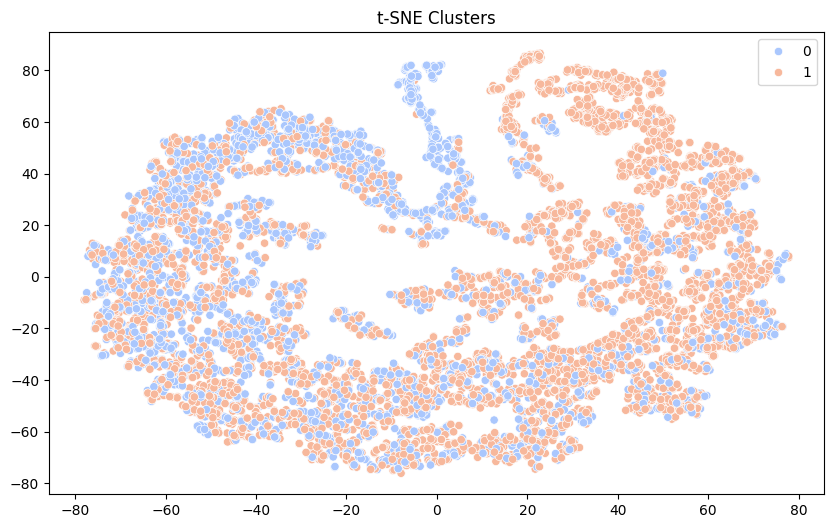


 SHAP Analysis...


NameError: name 'shap' is not defined

In [1]:
# --- ΒΗΜΑ 0: Εγκατάσταση Βιβλιοθηκών ---
try:
    import braindecode
    import shap
    import lime
    import captum
except ImportError:
    print(" Εγκατάσταση απαραίτητων βιβλιοθηκών...")
    !pip install -q braindecode mne shap lime captum scikit-learn

import os
import zipfile
import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from lime import lime_tabular
from captum.attr import LRP

# --- ΒΗΜΑ 1: Σύνδεση Drive & Εντοπισμός ZIP ---
print(" Σύνδεση με Google Drive...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

zip_paths = [
    '/content/DREAMER.zip',
    '/content/drive/MyDrive/DREAMER.zip'
]

target_zip = next((p for p in zip_paths if os.path.exists(p)), None)

if target_zip is None:
    print("\n ΣΦΑΛΜΑ: Δεν βρέθηκε το DREAMER.zip!")
else:
    # --- ΒΗΜΑ 2: Αποσυμπίεση ---
    extract_path = '/content/DREAMER_extracted'
    if not os.path.exists(extract_path):
        print("⏳ Ξεκινάει η αποσυμπίεση...")
        with zipfile.ZipFile(target_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_path)

    mat_path = None
    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.endswith('.mat') and 'DREAMER' in file:
                mat_path = os.path.join(root, file)
                break
        if mat_path: break

    # --- ΒΗΜΑ 3: Φόρτωση & Προεπεξεργασία ---
    def load_dreamer_gpu(path):
        print(f" Φόρτωση δεδομένων από: {path}")
        raw = sio.loadmat(path)
        data_struct = raw['DREAMER'][0, 0]['Data']
        X_list, y_list = [], []
        window_size, step = 128, 64

        for sub in range(23):
            try:
                eeg_root = data_struct[0, sub]['EEG'][0, 0]
                stimuli = eeg_root['stimuli'][0, 0] if 'stimuli' in eeg_root.dtype.names else eeg_root['Signals'][0, 0]
                valence = data_struct[0, sub]['ScoreValence'][0, 0]
            except: continue

            for trial in range(18):
                label = 1 if valence[trial, 0] >= 3 else 0
                signal = stimuli[trial, 0]
                limit = min(len(signal), 128*60)
                for start in range(0, limit - window_size, step):
                    seg = signal[start : start+window_size, :]
                    seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-6) # Normalization
                    X_list.append(seg.T)
                    y_list.append(label)

        X = np.array(X_list, dtype=np.float32)[:, np.newaxis, :, :]
        y = np.array(y_list, dtype=np.int64)
        return torch.tensor(X), torch.tensor(y)

    X_data, y_data = load_dreamer_gpu(mat_path)

    # --- ΒΗΜΑ 4: Αρχιτεκτονική ACTNN & Fine-Tuning ---
    class ACTNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.cnn = nn.Sequential(
                nn.Conv2d(1, 16, (14, 1)), nn.BatchNorm2d(16), nn.ELU(),
                nn.Conv2d(16, 32, (1, 10), stride=2), nn.BatchNorm2d(32), nn.ELU(), nn.Dropout(0.5)
            )
            self.transformer = nn.TransformerEncoder(
                nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True), num_layers=2)
            self.fc = nn.Linear(32, 2)
            self.attn = nn.Linear(32, 1)

        def forward(self, x):
            x = self.cnn(x).squeeze(2).permute(0, 2, 1)
            x = self.transformer(x)
            w = torch.softmax(self.attn(x), dim=1)
            return self.fc((x * w).sum(dim=1))

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ACTNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # ΔΙΟΡΘΩΣΗ: Αφαίρεση του verbose=True
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss()

    dataset = TensorDataset(X_data, y_data)
    train_len = int(0.8 * len(dataset))
    train_set, test_set = torch.utils.data.random_split(dataset, [train_len, len(dataset) - train_len])
    train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

    print(f"\n Training on {device}...")
    for epoch in range(15):
        model.train()
        train_correct = 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            train_correct += (out.argmax(1) == y).sum().item()

        model.eval()
        val_correct = 0
        with torch.no_grad():
            for X_v, y_v in test_loader:
                X_v, y_v = X_v.to(device), y_v.to(device)
                val_correct += (model(X_v).argmax(1) == y_v).sum().item()

        val_acc = val_correct / len(test_set)
        scheduler.step(val_acc)

        # Προαιρετικό: Χειροκίνητο print του LR αν θες να το βλέπεις
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d} | Train Acc: {train_correct/len(train_set):.2%} | Val Acc: {val_acc:.2%} | LR: {current_lr}")

    # --- ΒΗΜΑ 5: t-SNE ---
    print("\n t-SNE Visualization...")
    model.eval()
    f_list, l_list = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            feat = model.cnn(xb.to(device)).squeeze(2).permute(0, 2, 1)
            feat = model.transformer(feat).mean(dim=1)
            f_list.append(feat.cpu().numpy())
            l_list.append(yb.numpy())
    X_tsne = TSNE(n_components=2).fit_transform(np.concatenate(f_list))
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=np.concatenate(l_list), palette='coolwarm')
    plt.title("t-SNE Clusters")
    plt.show()

    # --- ΒΗΜΑ 6: SHAP ---
    print("\n SHAP Analysis...")
    batch = next(iter(test_loader))
    images, _ = batch
    # Χρήση λιγότερων background δειγμάτων για ταχύτητα
    explainer = shap.DeepExplainer(model, images[:30].to(device))
    shap_values = explainer.shap_values(images[30:32].to(device))

    # Διόρθωση για το dimensionality του SHAP output αν χρειαστεί
    shap.image_plot(shap_values, -images[30:32].numpy())

    # --- ΒΗΜΑ 7: LIME ---
    print("\n LIME Analysis...")
    def predict_p(x):
        x_t = torch.tensor(x, dtype=torch.float32).reshape(-1, 1, 14, 128).to(device)
        model.eval()
        with torch.no_grad():
            return torch.softmax(model(x_t), dim=1).cpu().numpy()

    expl_lime = lime_tabular.LimeTabularExplainer(
        X_data.numpy().reshape(len(X_data), -1),
        mode="classification",
        class_names=['Low Valence', 'High Valence']
    )
    exp = expl_lime.explain_instance(images[0].numpy().flatten(), predict_p)
    exp.as_pyplot_figure()
    plt.show()

    # --- ΒΗΜΑ 8: LRP ---
    print("\n LRP Heatmap...")
    model.eval()
    lrp = LRP(model)
    # Attribution για την κλάση High Valence (target=1)
    input_sample = images[0:1].to(device).requires_grad_(True)
    attr = lrp.attribute(input_sample, target=1)

    plt.figure(figsize=(12, 5))
    plt.imshow(attr.squeeze().cpu().detach().numpy(), aspect='auto', cmap='jet')
    plt.colorbar(label='Relevance')
    plt.title("LRP Relevance Map (Target: High Valence)")
    plt.ylabel("Channels (14)")
    plt.xlabel("Time Samples (128)")
    plt.show()


🔍 SHAP Analysis (GradientExplainer)...
📊 Τελικό Shape για Plotting: (14, 128)


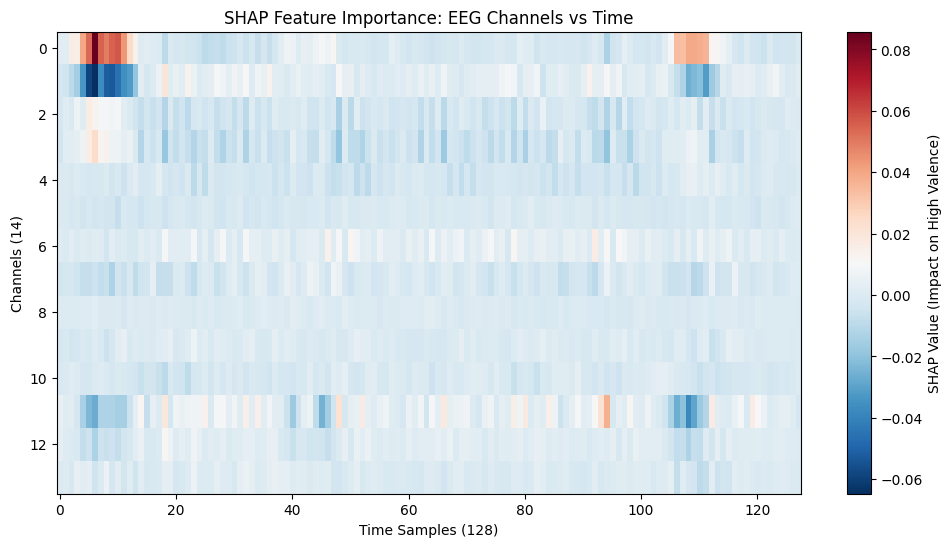

In [ ]:
# --- ΒΗΜΑ 6: SHAP Analysis (Οριστική Διόρθωση Shape) ---
print("\n🔍 SHAP Analysis (GradientExplainer)...")
model.eval()

batch = next(iter(test_loader))
images, _ = batch
background = images[:30].to(device)
test_images = images[30:31].to(device)

explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(test_images)

# Το shap_values έχει σχήμα (Samples, Color_Ch, EEG_Ch, Time, Classes) -> (1, 1, 14, 128, 2)
# 1. Αφαιρούμε τις περιττές διαστάσεις (squeeze)
shap_squeezed = np.squeeze(shap_values) # Γίνεται (14, 128, 2)

# 2. Επιλέγουμε την κλάση 1 (High Valence) από την τελευταία διάσταση
# Αν το σχήμα είναι (14, 128, 2), το shap_final θα γίνει (14, 128)
if shap_squeezed.ndim == 3:
    shap_final = shap_squeezed[:, :, 1]
else:
    shap_final = shap_squeezed

print(f"📊 Τελικό Shape για Plotting: {shap_final.shape}")

# Σχεδίαση
plt.figure(figsize=(12, 6))
plt.imshow(shap_final, aspect='auto', cmap='RdBu_r')
plt.colorbar(label='SHAP Value (Impact on High Valence)')
plt.title("SHAP Feature Importance: EEG Channels vs Time")
plt.ylabel("Channels (14)")
plt.xlabel("Time Samples (128)")
plt.show()


 LIME Analysis...


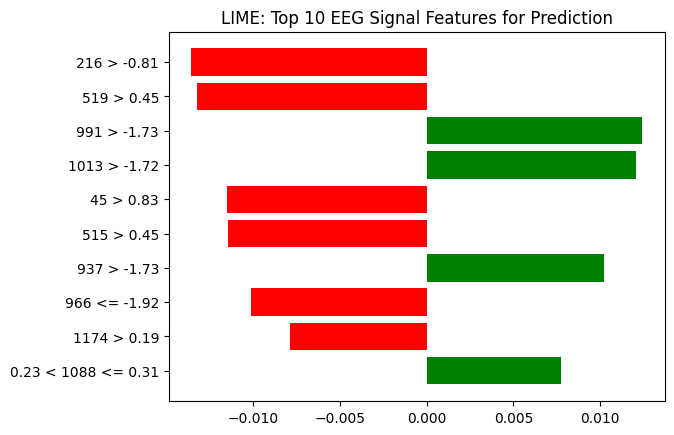

In [ ]:
# --- ΒΗΜΑ 7: LIME Analysis ---
print("\n LIME Analysis...")

def predict_p(x):
    # Μετατροπή του flat input σε (Batch, 1, 14, 128) για το ACTNN
    x_t = torch.tensor(x, dtype=torch.float32).reshape(-1, 1, 14, 128).to(device)
    model.eval()
    with torch.no_grad():
        return torch.softmax(model(x_t), dim=1).cpu().numpy()

# Προετοιμασία του explainer με flattened δεδομένα
expl_lime = lime_tabular.LimeTabularExplainer(
    X_data.numpy().reshape(len(X_data), -1),
    mode="classification",
    class_names=['Low Valence', 'High Valence']
)

# Εξήγηση ενός τυχαίου δείγματος από το test set
exp = expl_lime.explain_instance(images[0].numpy().flatten(), predict_p, num_features=10)
exp.as_pyplot_figure()
plt.title("LIME: Top 10 EEG Signal Features for Prediction")
plt.show()


🧬 Integrated Gradients Attribution...


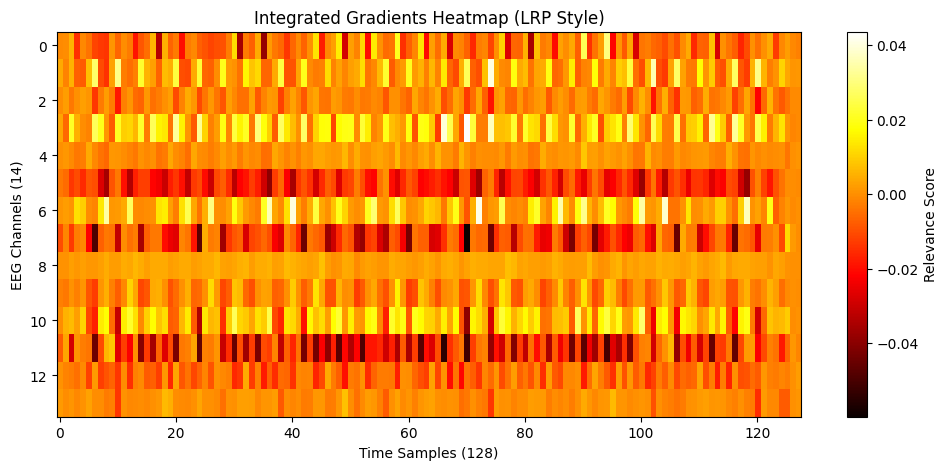

In [ ]:
# --- ΒΗΜΑ 8: Integrated Gradients (LRP Alternative) ---
from captum.attr import IntegratedGradients # <--- ΠΡΟΣΘΗΚΗ ΑΥΤΗΣ ΤΗΣ ΓΡΑΜΜΗΣ

print("\n🧬 Integrated Gradients Attribution...")

model.eval()
ig = IntegratedGradients(model)

# Παίρνουμε ένα δείγμα και ορίζουμε target=1 (High Valence)
# Βεβαιώσου ότι η μεταβλητή 'images' ορίζεται από το προηγούμενο κελί (batch = next(iter(test_loader)))
input_sample = images[0:1].to(device).requires_grad_(True)
attr = ig.attribute(input_sample, target=1)

# Squeeze για να πάρουμε τον πίνακα (Channels, Time) -> (14, 128)
attr_final = attr.squeeze().cpu().detach().numpy()

plt.figure(figsize=(12, 5))
plt.imshow(attr_final, aspect='auto', cmap='hot')
plt.colorbar(label='Relevance Score')
plt.title("Integrated Gradients Heatmap (LRP Style)")
plt.ylabel("EEG Channels (14)")
plt.xlabel("Time Samples (128)")
plt.show()

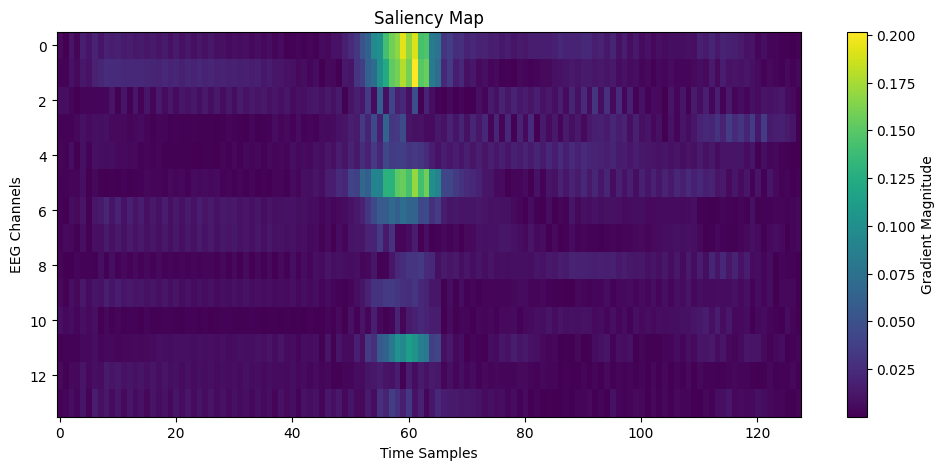

In [ ]:
from captum.attr import Saliency

# Εξασφαλίζουμε ότι έχουμε ένα δείγμα από το test_loader
batch = next(iter(test_loader))
images, _ = batch
input_sample = images[0:1].to(device).requires_grad_(True)

saliency = Saliency(model)
attr_saliency = saliency.attribute(input_sample, target=1)

plt.figure(figsize=(12, 5))
# Παίρνουμε την απόλυτη τιμή γιατί μας ενδιαφέρει η ένταση της αλλαγής
plt.imshow(np.abs(attr_saliency.squeeze().cpu().detach().numpy()), aspect='auto', cmap='viridis')
plt.colorbar(label='Gradient Magnitude')
plt.title("Saliency Map")
plt.ylabel("EEG Channels")
plt.xlabel("Time Samples")
plt.show()

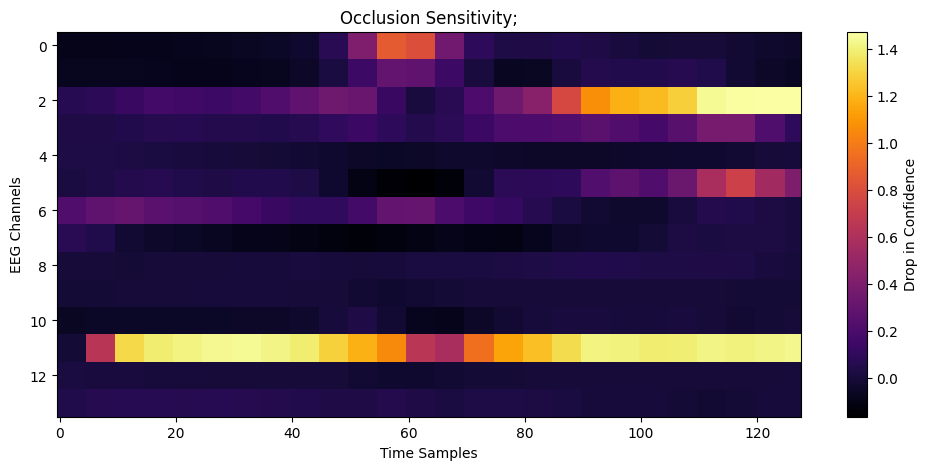

In [ ]:
from captum.attr import Occlusion

occlusion = Occlusion(model)

# Ορίζουμε sliding_window_shapes: (κανάλια, χρόνος) -> (1, 10)
# Σημαίνει ότι κρύβουμε 10 χρονικά δείγματα από 1 κανάλι τη φορά
attr_occ = occlusion.attribute(input_sample,
                               target=1,
                               strides=(1, 1, 5),
                               sliding_window_shapes=(1, 1, 10))

plt.figure(figsize=(12, 5))
plt.imshow(attr_occ.squeeze().cpu().detach().numpy(), aspect='auto', cmap='inferno')
plt.colorbar(label='Drop in Confidence')
plt.title("Occlusion Sensitivity;")
plt.ylabel("EEG Channels")
plt.xlabel("Time Samples")
plt.show()


 Running DeepLIFT Analysis...


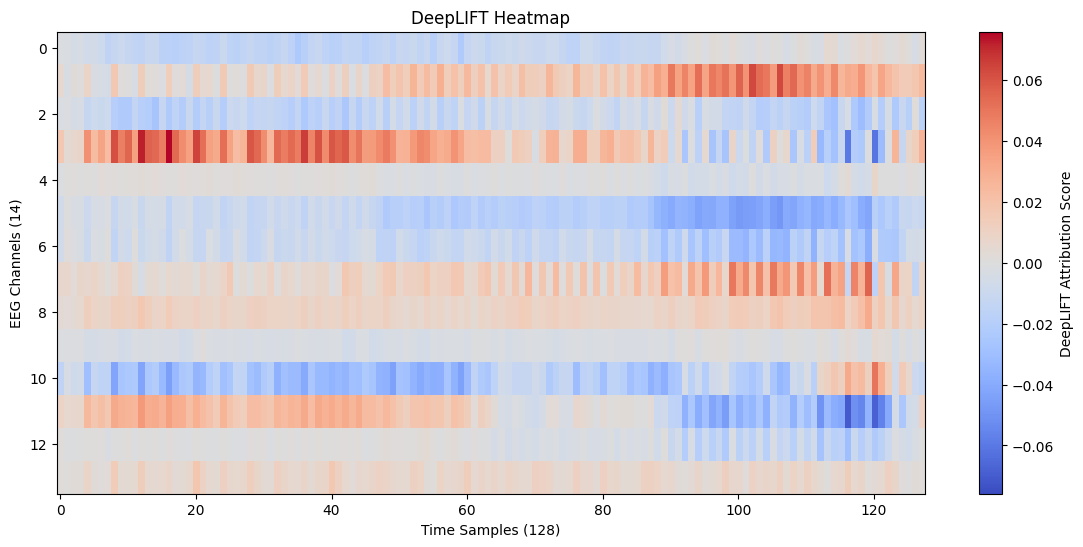

In [6]:
from captum.attr import DeepLift
import numpy as np
import matplotlib.pyplot as plt

# --- ΒΗΜΑ 8: DeepLIFT Analysis ---
print("\n Running DeepLIFT Analysis...")

# 1. Προετοιμασία του μοντέλου και του δείγματος
model.eval()
# Παίρνουμε ένα batch από το test_loader
batch = next(iter(test_loader))
images, labels = batch
# Επιλέγουμε το πρώτο δείγμα και ενεργοποιούμε τα gradients
input_sample = images[0:1].to(device).requires_grad_(True)

# 2. Ορισμός του DeepLIFT
dl = DeepLift(model)

# 3. Υπολογισμός των Attribution Scores
# Το target=1 αναφέρεται στην κλάση High Valence
# Αν δεν ορίσουμε baseline, η Captum χρησιμοποιεί αυτόματα μηδενικό πίνακα
attr_dl = dl.attribute(input_sample, target=1)

# 4. Μετατροπή σε numpy και καθαρισμός διαστάσεων (14 κανάλια x 128 δείγματα)
attr_dl_final = attr_dl.squeeze().cpu().detach().numpy()

# 5. Οπτικοποίηση με Heatmap
plt.figure(figsize=(14, 6))
# Χρησιμοποιούμε 'coolwarm' για να ξεχωρίζουν οι θετικές (κόκκινο)
# και οι αρνητικές (μπλε) συνεισφορές
v_max = np.max(np.abs(attr_dl_final)) # Για συμμετρική κλίμακα χρωμάτων
im = plt.imshow(attr_dl_final, aspect='auto', cmap='coolwarm', vmin=-v_max, vmax=v_max)

plt.colorbar(im, label='DeepLIFT Attribution Score')
plt.title("DeepLIFT Heatmap")
plt.ylabel("EEG Channels (14)")
plt.xlabel("Time Samples (128)")

# Προαιρετικά: Αν έχεις λίστα με τα ονόματα των καναλιών, μπορείς να τα προσθέσεις:
# channels = ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4']
# plt.yticks(range(14), channels)

plt.show()


 Extracting Attention Weights...


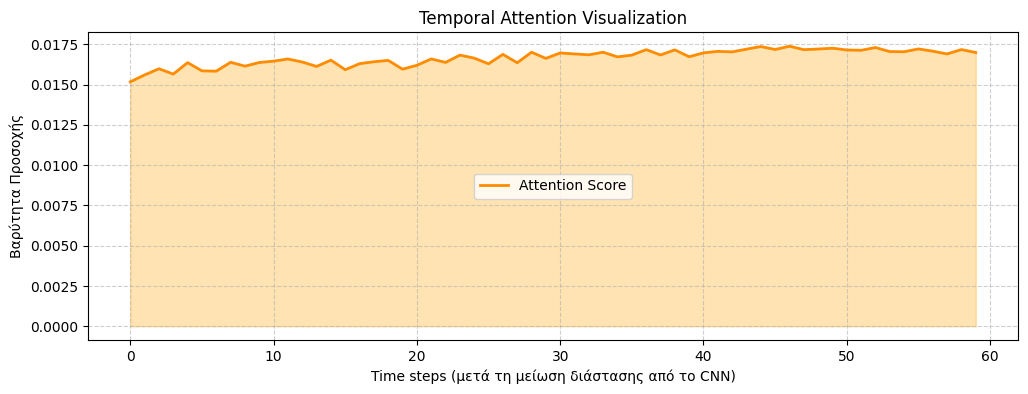

In [7]:
# --- ΒΗΜΑ 9: Attention Weights Visualization (Διορθωμένο) ---
print("\n Extracting Attention Weights...")

model.eval()

# 1. Εξασφάλιση δείγματος (αν δεν υπάρχει το input_sample)
try:
    x = input_sample.to(device)
except NameError:
    # Παίρνουμε ένα νέο batch αν το input_sample δεν είναι ορισμένο
    batch = next(iter(test_loader))
    images, _ = batch
    x = images[0:1].to(device)

with torch.no_grad():
    # 2. Περνάμε από το CNN
    # (Σημείωση: Οι ονομασίες model.cnn, model.transformer, κλπ.
    # πρέπει να αντιστοιχούν ακριβώς στα ονόματα που έδωσες στο __init__ του ACTNN)
    x_cnn = model.cnn(x).squeeze(2).permute(0, 2, 1)

    # 3. Περνάμε από τον Transformer
    x_trans = model.transformer(x_cnn)

    # 4. Υπολογισμός των Attention Weights
    attn_scores = model.attn(x_trans)
    attn_weights = torch.softmax(attn_scores, dim=1).cpu().numpy().squeeze()

# 5. Οπτικοποίηση
plt.figure(figsize=(12, 4))
plt.plot(attn_weights, color='darkorange', linewidth=2, label='Attention Score')
plt.fill_between(range(len(attn_weights)), attn_weights, alpha=0.3, color='orange')
plt.title("Temporal Attention Visualization")
plt.xlabel("Time steps (μετά τη μείωση διάστασης από το CNN)")
plt.ylabel("Βαρύτητα Προσοχής")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


 Running KernelSHAP (Sampling-based)...


  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/shap/explainers/_kernel.py:765: UserWarning: Linear regression equation is singular, a least squares solutions is used instead.
To avoid this situation and get a regular matrix do one of the following:
1) turn up the number of samples,
2) turn up the L1 regularization with num_features(N) where N is less than the number of samples,
3) group features together to reduce the number of inputs that need to be explained.
  warnings.warn(


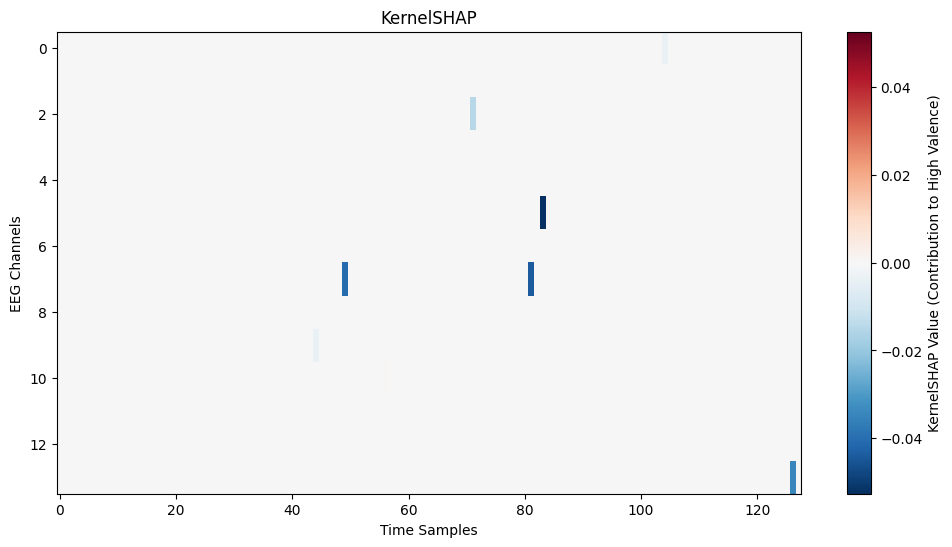

In [12]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- ΒΗΜΑ 10: KernelSHAP Analysis (Διορθωμένο) ---
print("\n Running KernelSHAP (Sampling-based)...")

model.eval()

# 1. Συνάρτηση πρόβλεψης που επιστρέφει ΜΟΝΟ την πιθανότητα της κλάσης-στόχου (High Valence)
def predict_fn(x_flat):
    x_tensor = torch.tensor(x_flat, dtype=torch.float32).reshape(-1, 1, 14, 128).to(device)
    with torch.no_grad():
        # Επιστρέφουμε την πιθανότητα για την κλάση 1 (High Valence)
        probs = torch.softmax(model(x_tensor), dim=1)
        return probs[:, 1].cpu().numpy() # Επιστρέφουμε (N,) αντί για (N, 2)

# 2. Προετοιμασία δεδομένων
try:
    test_input_flat = input_sample.detach().cpu().reshape(1, -1).numpy()
except NameError:
    batch = next(iter(test_loader))
    images, _ = batch
    test_input_flat = images[0:1].detach().cpu().reshape(1, -1).numpy()

background_flat = images.detach().cpu().reshape(len(images), -1).numpy()
background_summary = shap.kmeans(background_flat, 10)

# 3. Εκτέλεση KernelExplainer
explainer_kernel = shap.KernelExplainer(predict_fn, background_summary)

# Χρησιμοποιούμε nsamples=100. Αν είναι πολύ αργό, δοκίμασε nsamples=50.
shap_values_kernel = explainer_kernel.shap_values(test_input_flat, nsamples=100)

# 4. Διαχείριση του αποτελέσματος (Handling single-output SHAP values)
# Αν επιστρέψαμε μόνο μία κλάση στο predict_fn, το shap_values_kernel είναι πίνακας (1, 1792)
if isinstance(shap_values_kernel, list):
    # Περίπτωση πολλαπλών εξόδων
    shap_plot_data = np.array(shap_values_kernel[0]).reshape(14, 128)
else:
    # Περίπτωση μονής εξόδου
    shap_plot_data = shap_values_kernel.reshape(14, 128)

# 5. Οπτικοποίηση
plt.figure(figsize=(12, 6))
v_max = np.max(np.abs(shap_plot_data))
plt.imshow(shap_plot_data, aspect='auto', cmap='RdBu_r', vmin=-v_max, vmax=v_max)
plt.colorbar(label='KernelSHAP Value (Contribution to High Valence)')
plt.title("KernelSHAP")
plt.ylabel("EEG Channels")
plt.xlabel("Time Samples")
plt.show()


🔮 Running KernelSHAP (Sampling-based)...


  0%|          | 0/1 [00:00<?, ?it/s]

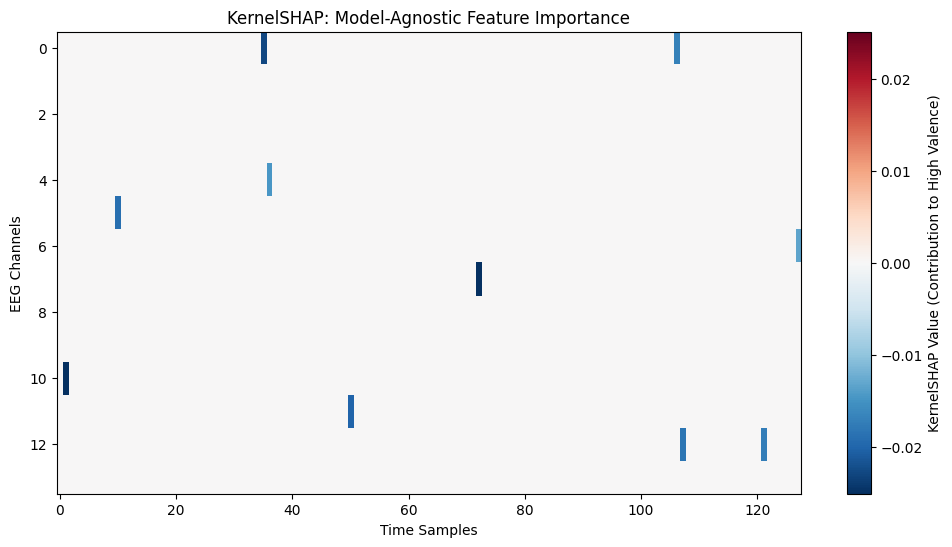

In [13]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt

# --- ΒΗΜΑ 10: KernelSHAP Analysis (Διορθωμένο) ---
print("\n🔮 Running KernelSHAP (Sampling-based)...")

model.eval()

# 1. Συνάρτηση πρόβλεψης που επιστρέφει ΜΟΝΟ την πιθανότητα της κλάσης-στόχου (High Valence)
def predict_fn(x_flat):
    x_tensor = torch.tensor(x_flat, dtype=torch.float32).reshape(-1, 1, 14, 128).to(device)
    with torch.no_grad():
        # Επιστρέφουμε την πιθανότητα για την κλάση 1 (High Valence)
        probs = torch.softmax(model(x_tensor), dim=1)
        return probs[:, 1].cpu().numpy() # Επιστρέφουμε (N,) αντί για (N, 2)

# 2. Προετοιμασία δεδομένων
try:
    test_input_flat = input_sample.detach().cpu().reshape(1, -1).numpy()
except NameError:
    batch = next(iter(test_loader))
    images, _ = batch
    test_input_flat = images[0:1].detach().cpu().reshape(1, -1).numpy()

background_flat = images.detach().cpu().reshape(len(images), -1).numpy()
background_summary = shap.kmeans(background_flat, 10)

# 3. Εκτέλεση KernelExplainer
explainer_kernel = shap.KernelExplainer(predict_fn, background_summary)

# Χρησιμοποιούμε nsamples=100. Αν είναι πολύ αργό, δοκίμασε nsamples=50.
shap_values_kernel = explainer_kernel.shap_values(test_input_flat, nsamples=1000)

# 4. Διαχείριση του αποτελέσματος (Handling single-output SHAP values)
# Αν επιστρέψαμε μόνο μία κλάση στο predict_fn, το shap_values_kernel είναι πίνακας (1, 1792)
if isinstance(shap_values_kernel, list):
    # Περίπτωση πολλαπλών εξόδων
    shap_plot_data = np.array(shap_values_kernel[0]).reshape(14, 128)
else:
    # Περίπτωση μονής εξόδου
    shap_plot_data = shap_values_kernel.reshape(14, 128)

# 5. Οπτικοποίηση
plt.figure(figsize=(12, 6))
v_max = np.max(np.abs(shap_plot_data))
plt.imshow(shap_plot_data, aspect='auto', cmap='RdBu_r', vmin=-v_max, vmax=v_max)
plt.colorbar(label='KernelSHAP Value (Contribution to High Valence)')
plt.title("KernelSHAP: Model-Agnostic Feature Importance")
plt.ylabel("EEG Channels")
plt.xlabel("Time Samples")
plt.show()

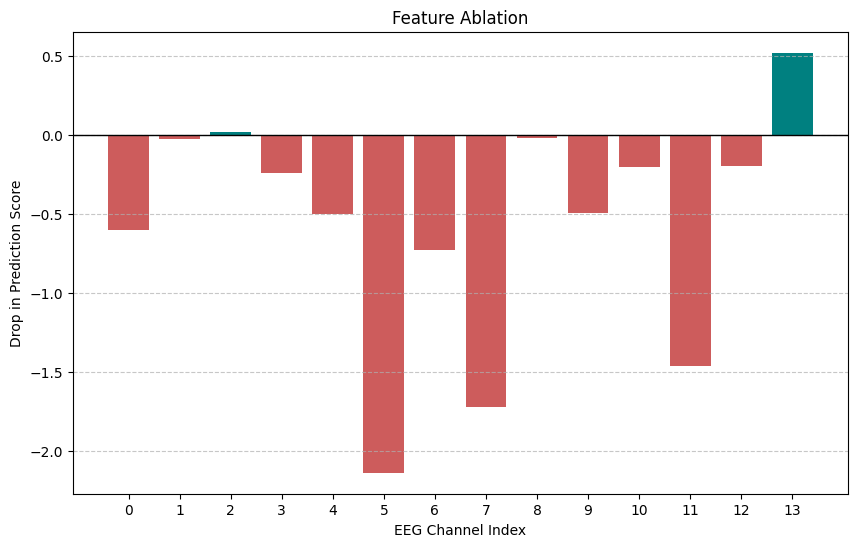

In [15]:
from captum.attr import FeatureAblation

# 1. Ορισμός του Ablator
ablator = FeatureAblation(model)

# 2. Δημιουργία mask για να αφαιρούμε ολόκληρα κανάλια (14 κανάλια)
# Ορίζουμε ότι κάθε κανάλι είναι ένα ενιαίο feature που πρέπει να αφαιρεθεί
feature_mask = torch.arange(14).reshape(1, 1, 14, 1).expand(1, 1, 14, 128).to(device)

# 3. Υπολογισμός Attribution
attr_ablation = ablator.attribute(input_sample, target=1, feature_mask=feature_mask)

# 4. Υπολογισμός μέσης τιμής ανά κανάλι για το Bar Chart
channel_importance = attr_ablation.squeeze().mean(dim=1).cpu().detach().numpy()

# 5. Οπτικοποίηση
plt.figure(figsize=(10, 6))
colors = ['teal' if val >= 0 else 'indianred' for val in channel_importance]
plt.bar(range(14), channel_importance, color=colors)
plt.axhline(0, color='black', lw=1)
plt.title("Feature Ablation")
plt.xlabel("EEG Channel Index")
plt.ylabel("Drop in Prediction Score")
plt.xticks(range(14))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

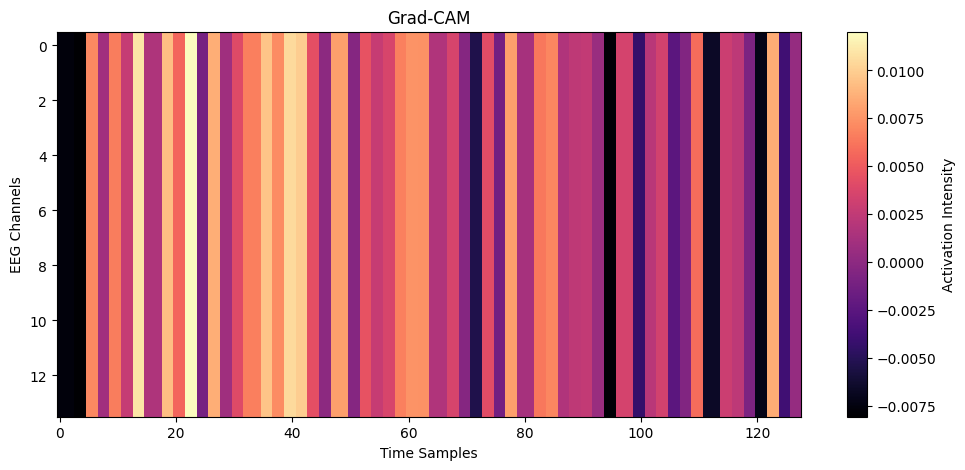

In [17]:
from captum.attr import LayerGradCam

# 1. Ορίζουμε το layer στόχο (το τελευταίο layer του CNN σου)
# Αν στο ACTNN το έχεις ονομάσει π.χ. self.cnn, στοχεύουμε το τελευταίο conv block
target_layer = model.cnn[-1]

lgc = LayerGradCam(model, target_layer)

# 2. Υπολογισμός Attribution στο επίπεδο των feature maps
attr_gradcam = lgc.attribute(input_sample, target=1)

# 3. Upsampling για να ταιριάξει με τις διαστάσεις της εισόδου (14x128)
attr_gradcam_upsampled = LayerGradCam.interpolate(attr_gradcam, (14, 128))
gradcam_data = attr_gradcam_upsampled.squeeze().cpu().detach().numpy()

# 4. Οπτικοποίηση
plt.figure(figsize=(12, 5))
plt.imshow(gradcam_data, aspect='auto', cmap='magma')
plt.colorbar(label='Activation Intensity')
plt.title("Grad-CAM")
plt.ylabel("EEG Channels")
plt.xlabel("Time Samples")
plt.show()